18:18:50 - cmdstanpy - INFO - Chain [1] start processing
18:18:50 - cmdstanpy - INFO - Chain [1] done processing


Test MAE: 4.06
Test WAPE: 2.31%


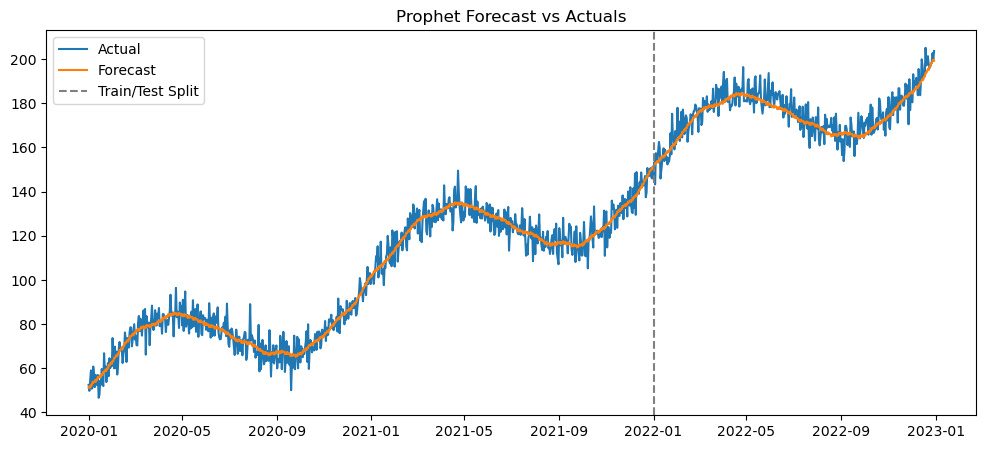

In [12]:

from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error

# Generate synthetic data
np.random.seed(42)
days = pd.date_range(start='2020-01-01', periods=1095)  # 3 years
trend = np.linspace(50, 200, 1095)
seasonality = 20 * np.sin(np.linspace(0, 6 * np.pi, 1095))  # yearly seasonality
noise = np.random.normal(0, 5, 1095)
sales = trend + seasonality + noise

df = pd.DataFrame({'ds': days, 'y': sales})

# Split data: train = first 2 years, test = last 1 year
train_df = df[df['ds'] < '2022-01-01']
test_df = df[df['ds'] >= '2022-01-01']

# Fit model on training data
m = Prophet()
m.fit(train_df)

# Make future dataframe for test period
future = m.make_future_dataframe(periods=len(test_df), freq='D')
forecast = m.predict(future)

# Merge predictions with actual test data
merged = test_df.merge(forecast[['ds', 'yhat']], on='ds')

# Evaluate on test set
mae = mean_absolute_error(merged['y'], merged['yhat'])
wape = np.sum(np.abs(merged['y'] - merged['yhat'])) / np.sum(np.abs(merged['y']))

print(f"Test MAE: {mae:.2f}")
print(f"Test WAPE: {wape * 100:.2f}%")

# Optional: plot full forecast vs actuals
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df['ds'], df['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast')
plt.axvline(pd.to_datetime('2022-01-01'), color='gray', linestyle='--', label='Train/Test Split')
plt.legend()
plt.title("Prophet Forecast vs Actuals")
plt.show()

In [4]:
# Step 1: Install Prophet
#!pip install prophet

## Interpretation

MAE:

“On average, my prediction is 4.06 units higher or lower than the actual observed value.”
If sales range from, say, 20 to 60 units, an error of 4.06 is pretty small — this is good.

WAPE:

This means that, across the entire time series, total forecast error is just 2.31% of total actual demand.
“The total forecast error is 2.31% of the total true demand — meaning the model is about 97.69% accurate overall.”
💡 Many forecasting teams use:

<10% WAPE = excellent
10–20% = solid
20–30% = needs improvement
So 2.31% is very good — especially for a simple Prophet model on synthetic data.


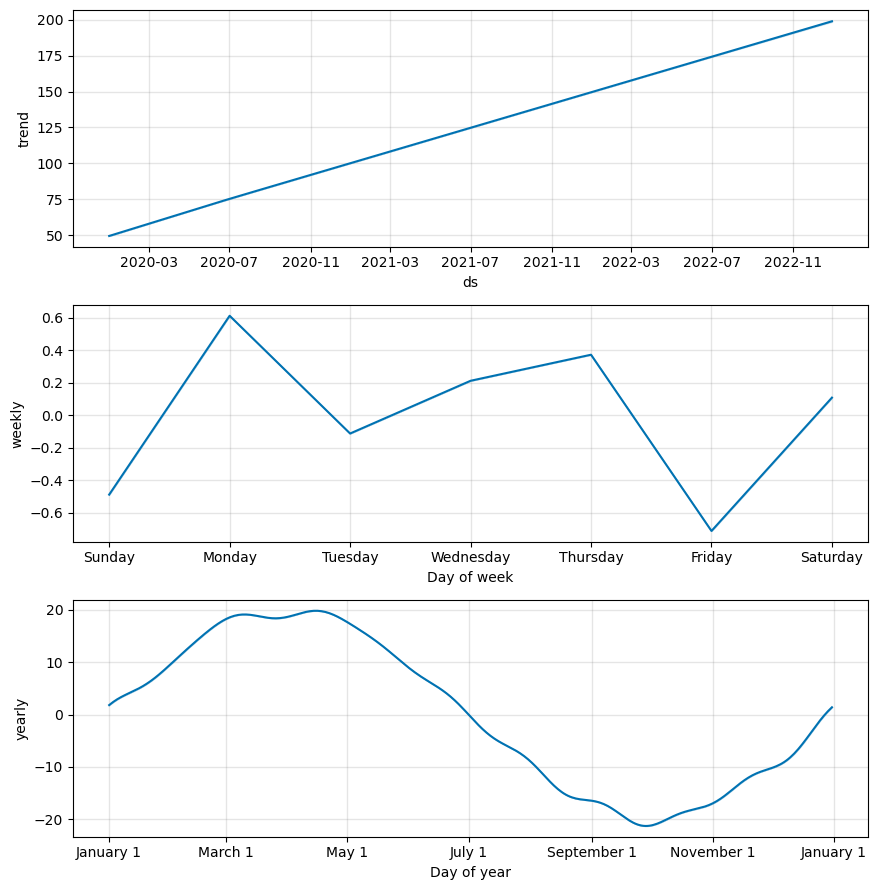

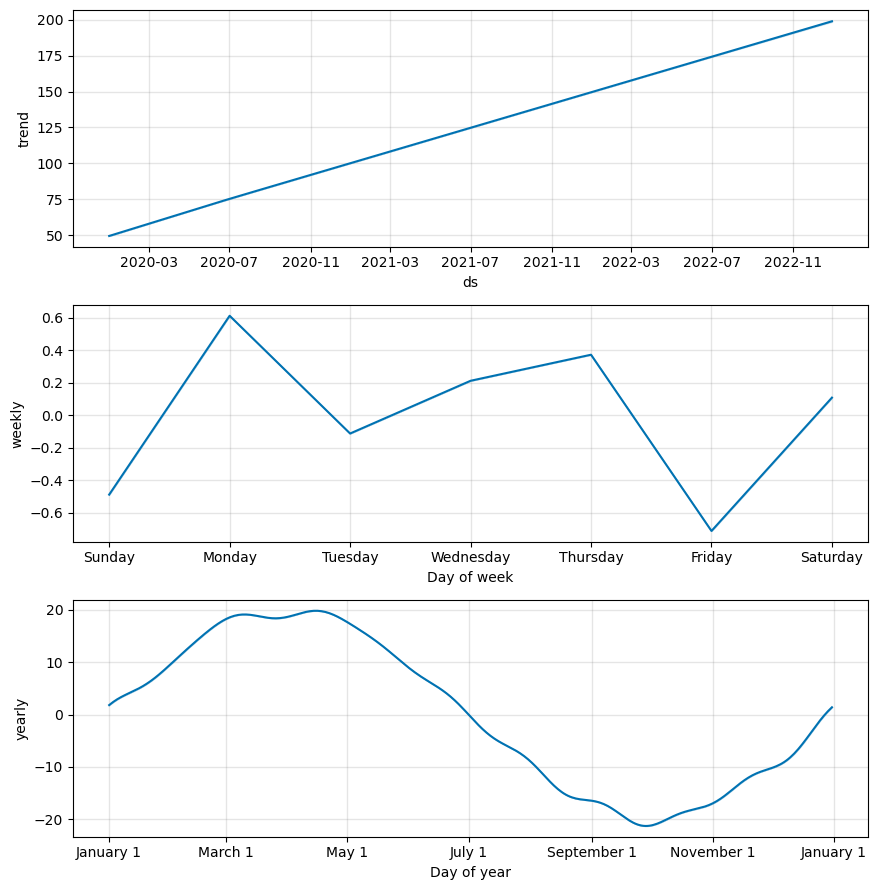

In [17]:
m.plot_components(forecast)

## Add holidays

In [20]:
from prophet import Prophet
from prophet.serialize import model_to_json, model_from_json
from prophet.make_holidays import make_holidays_df

# Add built-in US holidays
m = Prophet(holidays=make_holidays_df(year_list=[2020, 2021, 2022], country='US'))
m.fit(train_df)

18:34:41 - cmdstanpy - INFO - Chain [1] start processing
18:34:41 - cmdstanpy - INFO - Chain [1] done processing


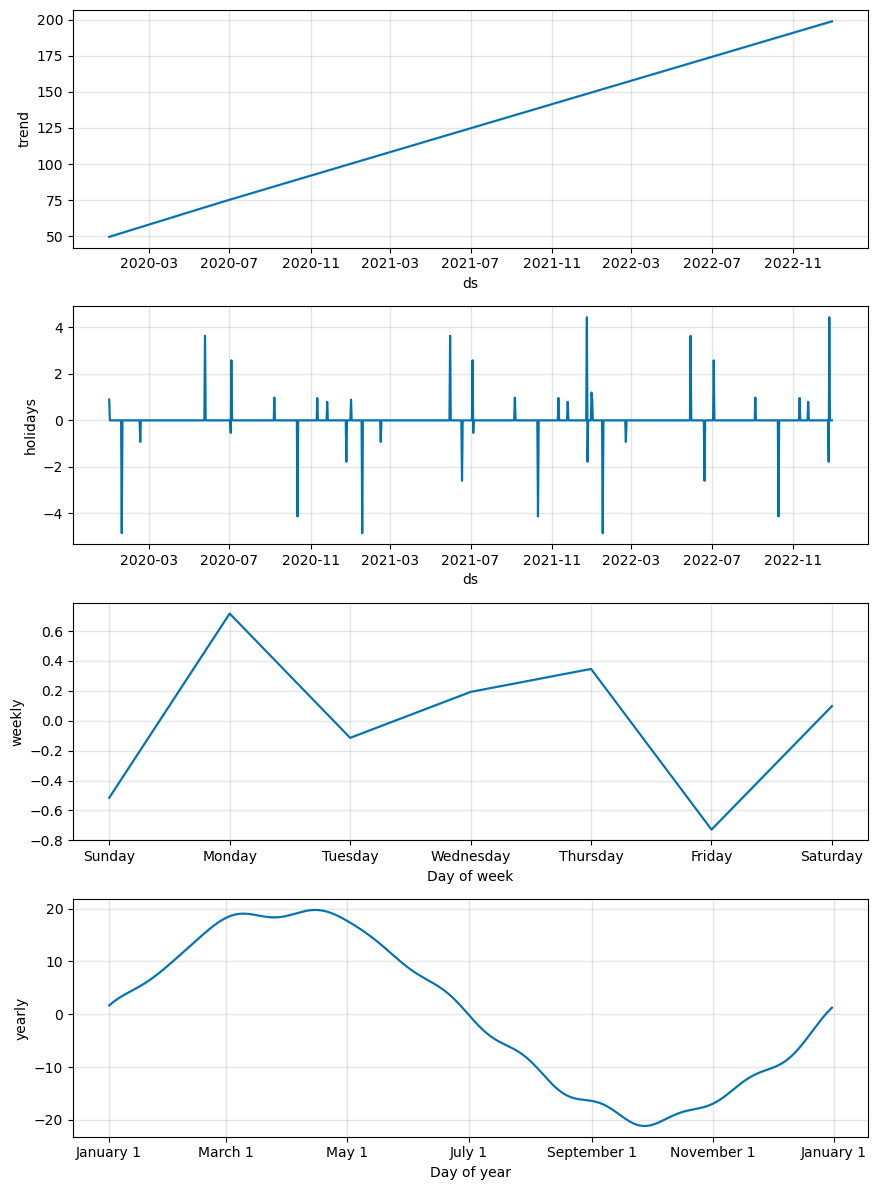

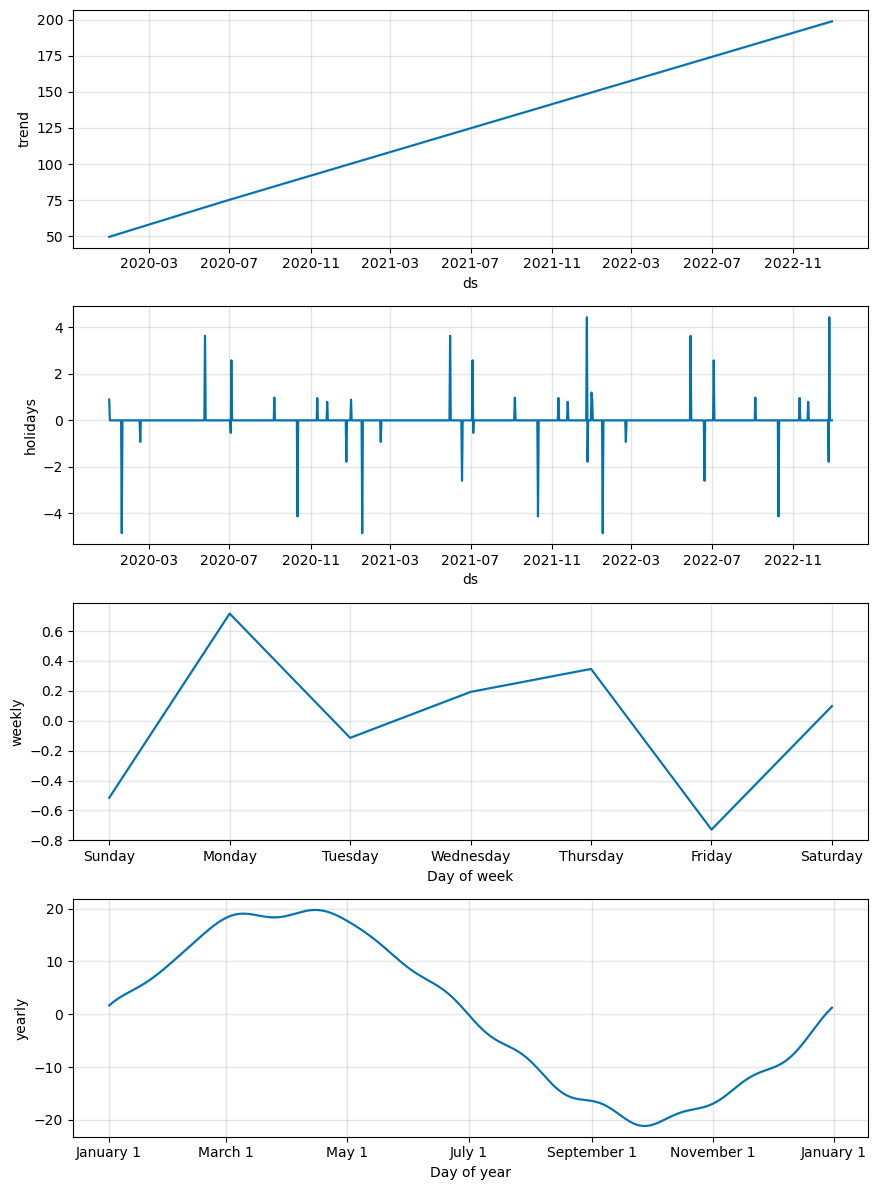

In [27]:
forecast = m.predict(future)
m.plot_components(forecast)

## Forecast Close Look for January 2022

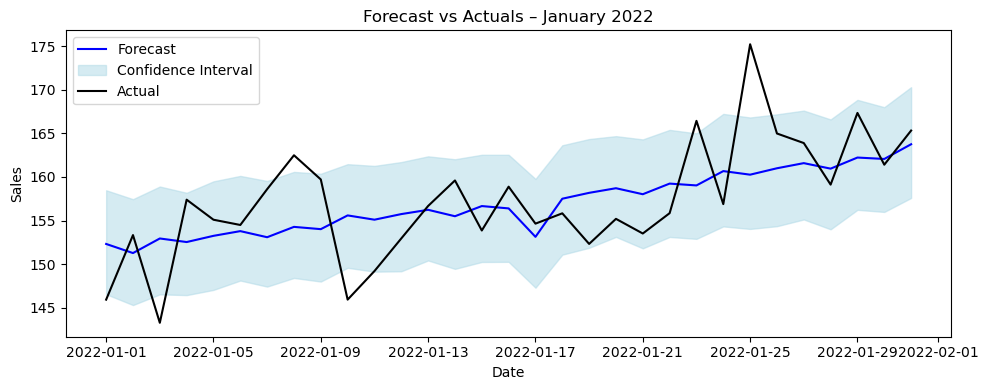

In [24]:

# Filter forecast for January 2022
forecast_jan = forecast[(forecast['ds'] >= '2022-01-01') & (forecast['ds'] < '2022-02-01')]

# (Optional) Get actuals for Jan 2022 if you want to compare
actual_jan = df[(df['ds'] >= '2022-01-01') & (df['ds'] < '2022-02-01')]

# Plot forecast
plt.figure(figsize=(10, 4))
plt.plot(forecast_jan['ds'], forecast_jan['yhat'], label='Forecast', color='blue')
plt.fill_between(forecast_jan['ds'], forecast_jan['yhat_lower'], forecast_jan['yhat_upper'], color='lightblue', alpha=0.5, label='Confidence Interval')

# Optional: add actuals
plt.plot(actual_jan['ds'], actual_jan['y'], label='Actual', color='black')

plt.title("Forecast vs Actuals – January 2022")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()